<a href="https://colab.research.google.com/github/wcaine93/Advanced-Python-Project/blob/main/src/nn-with-increased-epochs-training-and-evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B: Split the data into training and testing data

In [3]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

df = pd.read_csv('clean_data.csv')

### 1. Create the data features (X) and target labels (y).  

In [4]:
X = df.drop('Strength', axis=1)
y = df['Strength']

### 2. Randomly split the data features and labels into a training and test sets by holding 30% of the data for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# E: Increase the number of epochs

1. Repeat Part C but use 250 epochs this time for training.  
2. prevent the overfitting using tensorflow.keras.callbacks.EarlyStopping(), if 30 epochs with no improvement by monitoring the validation loss, the training will be stopped,  

## Baseline Model


In [26]:
baseline_model = tf.keras.models.Sequential([
  tf.keras.Input(shape=(8,)),
  tf.keras.layers.Dense(10, activation='relu'),
  tf.keras.layers.Dense(10, activation='relu'),
  tf.keras.layers.Dense(1)
])

In [27]:
baseline_model.build()

### 2. Plot the model architecture

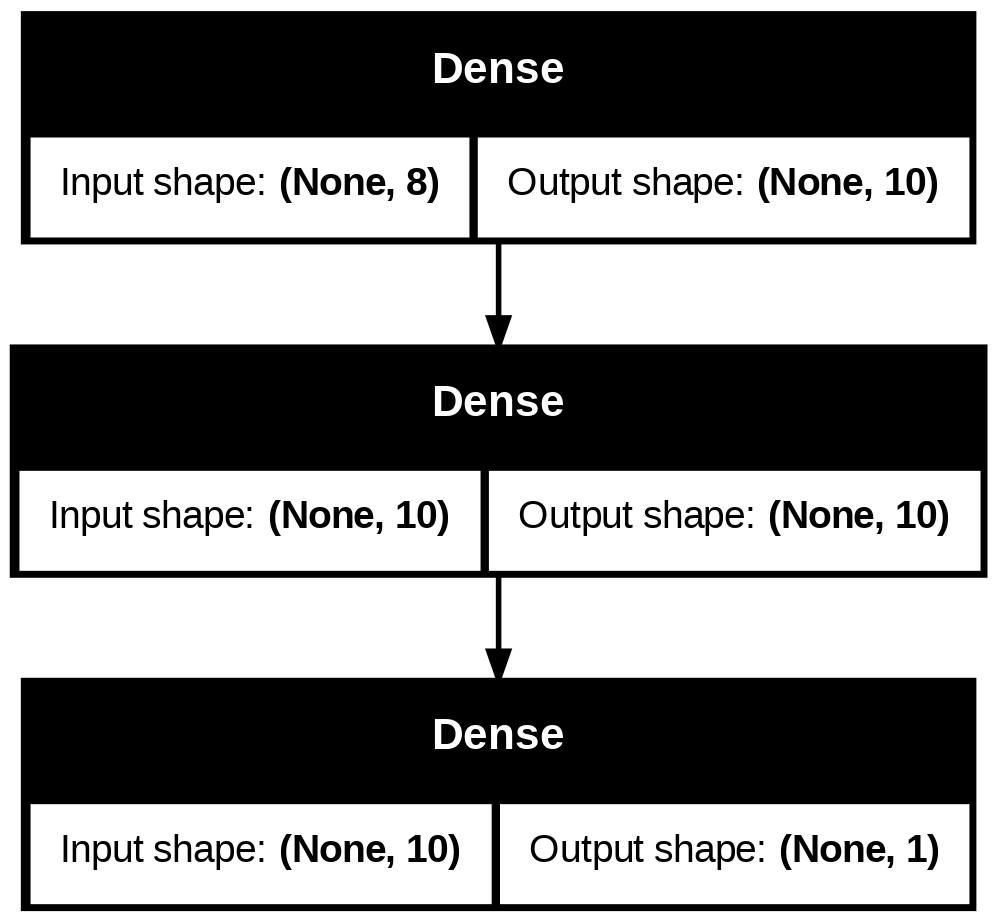

In [28]:
tf.keras.utils.plot_model(baseline_model, to_file='baseline_model.png', show_shapes=True)

### 3. Compile the model using the adam as the optimizer and using the mean squared error as the loss function.

In [29]:
baseline_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

## Include EarlyStopping and extra epochs

### 4. Train the model on the training data

In [30]:
baseline_model.fit(
    X_train, y_train,
    epochs=250,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=30)]
)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 276500.8438   
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 95714.2031  
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23374.4277 
Epoch 4/250
 1/22 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6595.0942

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3830.0354 
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 637.1391 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 424.3408 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 466.4062 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 455.6985 
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 427.5181 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 431.5497 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 416.1000 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 391.9705 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 434.2418 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 353.1170 
Epoch 15/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 349.4108 
Epoch 16/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 357.3133 
Epoch 17/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 335.4735 
Epoch 18/250
22/22 ━━━━━━━━━━━━━━━━━━

### 5. Evaluate the model on the test data using model.evaluate

In [31]:
baseline_model.evaluate(X_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 69.7245  


71.59891510009766

Ultimate MSE of `71.599`

### 6. Make predictions on test data using model.predict

In [32]:
baseline_model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([[25.883568 ],
       [19.736    ],
       [34.79557  ],
       [38.417015 ],
       [48.75448  ],
       [26.573235 ],
       [18.939323 ],
       [39.24379  ],
       [27.41784  ],
       [44.518227 ],
       [34.422043 ],
       [28.493553 ],
       [41.79667  ],
       [46.813637 ],
       [30.105911 ],
       [18.875679 ],
       [38.672462 ],
       [46.523056 ],
       [47.495872 ],
       [45.16073  ],
       [36.398804 ],
       [10.783348 ],
       [38.37381  ],
       [30.799873 ],
       [10.728874 ],
       [31.389778 ],
       [52.87652  ],
       [31.341331 ],
       [20.676918 ],
       [51.62063  ],
       [46.087273 ],
       [52.550972 ],
       [55.488564 ],
       [48.101128 ],
       [21.819862 ],
       [59.537987 ],
       [40.39817  ],
       [50.971687 ],
       [46.48176  ],
       [81.95516  ],
       [38.42907  ],
       [28.983162 ],
       [33.857178 ],
       [43.41764  ],
       [52.934868 ],
       [49.429115 ],
       [57.131004 ],
       [25.69